In [402]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [403]:
# Load dataframe
df = pd.read_csv("../data/raw/listings.csv")

In [404]:
detail_ratings = ["review_scores_cleanliness", "review_scores_checkin", 
               "review_scores_communication", "review_scores_location", 
               "review_scores_accuracy", "review_scores_value"]

In [405]:
# Load relevant columns of the more detailed dataframe, based on domain-knowledge
add_df = pd.read_csv(
    "../data/raw/listings.csv.gz",
    usecols=["id"] + detail_ratings + ["review_scores_rating", "host_is_superhost", "beds", "bedrooms", "accommodates", "instant_bookable"]
)

In [406]:
# Merge both dataframes
df = df.merge(
    add_df,
    on="id",
    how="left"
)
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,bedrooms,beds,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,31840,Residenza Martin Classic room,380378,Andrea,NaN,Centro Storico,43.77709,11.25216,Private room,147.0,...,1.0,1.0,4.67,4.74,4.84,4.86,4.90,4.88,4.67,t
1,32180,Charming Gem - Oltrarno City centre,13925330,Cesare,NaN,Centro Storico,43.76832,11.24348,Entire home/apt,121.0,...,2.0,3.0,4.76,4.82,4.82,4.79,4.72,4.82,4.85,f
2,39115,Central Double Shared Bathroom,167739,Lorenzo,NaN,Centro Storico,43.77525,11.25258,Private room,77.0,...,1.0,1.0,4.52,4.70,4.61,4.80,4.74,4.91,4.55,f


## Data Cleaning

### Column Selection

`neighbourhood_group` has no existing values, therefore remove it.

In [408]:
not_null_count = df["neighbourhood_group"].notna().sum()
print(f"Number of existing values: {not_null_count}")

# Remove column
df = df.drop(columns=["neighbourhood_group"])

Number of existing values: 0


Remove columns with no useful information on the price (except the id):

In [ ]:
df = df.drop(columns=["name", "host_id", "host_name", "license"])

Remove columns based on domain knowledge:

In [409]:
df = df.drop(columns = ["minimum_nights", "last_review", "calculated_host_listings_count", "availability_365"])

`reviews_per_month` is redundant because of `number_of_reviews`, therefore remove it.

In [410]:
df = df.drop(columns="reviews_per_month")

When the overall rating `review_scores_rating` is available, then all the more detailed ratings are also available:

In [399]:
mask = df["review_scores_rating"].notna()
print("Number of missing values of detailed ratings, when overall rating exists:")
print(df.loc[mask, detail_ratings].isna().sum())

Number of missing values of detailed ratings, when overall rating exists:
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_accuracy         0
review_scores_value            0
dtype: int64


The overall rating `review_scores_rating` includes the price-performance ratio `review_scores_value`, which is directly influenced by price and would introduce reverse causality.

Because of the completeness of the more detailed ratings, I choose to use the average of all detailed ratings, excluding `review_scores_value`, instead of `review_scores_rating`:

In [400]:
# Compute custom rating
rating_cols = [col for col in detail_ratings if col != "review_scores_value"]
df["avg_rating"] = df[rating_cols].mean(axis=1)

# Remove other ratings
df = df.drop(columns=detail_ratings+["review_scores_rating"])

### Target Variable (Price)

#### Missing Values

Missing price values are removed, because price is the target variable and cannot be imputed

In [411]:
missing_percent = df["price"].isna().mean()*100
print(f"Missing price values: {missing_percent:.1f}%")

# Remove rows with missing price values
df = df.dropna(subset=["price"])

Missing price values: 8.8%


#### Outliers

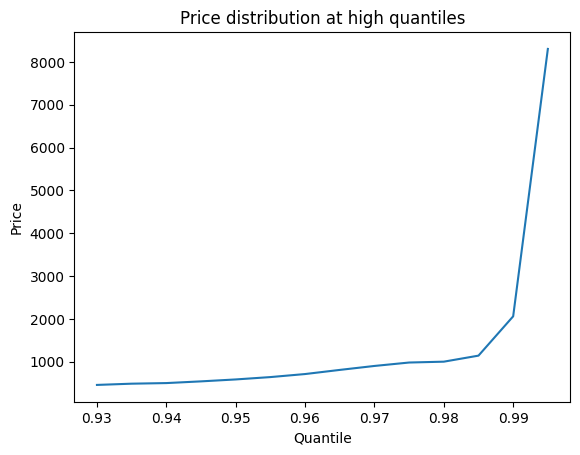

In [302]:
quantiles = np.arange(0.93, 1.0, 0.005)
values = df["price"].quantile(quantiles)
plt.plot(quantiles, values)
plt.xlabel("Quantile")
plt.ylabel("Price")
plt.title("Price distribution at high quantiles")
plt.show()

Listings above the 98.5th percentile are removed, because the quantile plot shows a steep increase after this point, indicating luxury properties that are not representative of typical Airbnb listings in Florence.

In [303]:
q985 = df["price"].quantile(0.985)
df = df[df["price"]<=q985]

In [304]:
df.sort_values("price").head(100)

,id,neighbourhood,latitude,longitude,room_type,price,number_of_reviews,number_of_reviews_ltm,host_is_superhost,accommodates,bedrooms,beds,review_scores_rating,instant_bookable
4279,42778456,Campo di Marte,43.773980,11.293060,Private room,10.0,0,0,f,2.0,1.0,2.0,NaN,f
3275,31568220,Centro Storico,43.783000,11.233810,Private room,12.0,0,0,f,1.0,1.0,1.0,NaN,f
4953,51789949,Centro Storico,43.782020,11.233540,Private room,13.0,0,0,f,2.0,1.0,2.0,NaN,f
3661,35393146,Centro Storico,43.782800,11.235870,Private room,13.0,0,0,f,2.0,1.0,1.0,NaN,f
11443,1354283339722146630,Rifredi,43.797140,11.198730,Shared room,15.0,4,4,f,1.0,1.0,2.0,2.50,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,3279605,Campo di Marte,43.772580,11.272990,Private room,40.0,264,35,t,2.0,1.0,1.0,4.61,f
1647,13747574,Campo di Marte,43.773682,11.276744,Private room,40.0,15,0,f,2.0,1.0,1.0,4.67,f
8491,1037465542821324703,Rifredi,43.798160,11.198430,Entire home/apt,40.0,1,0,f,2.0,1.0,1.0,3.00,f
5970,678047309084466611,Centro Storico,43.771350,11.270340,Private room,40.0,28,0,t,2.0,1.0,1.0,4.82,f


<Axes: >

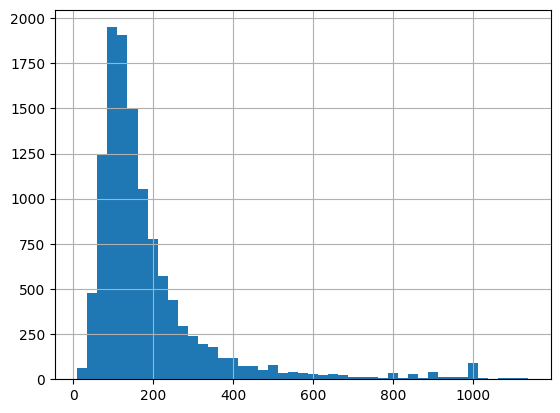

In [305]:
df["price"].hist(bins=45)

<Axes: >

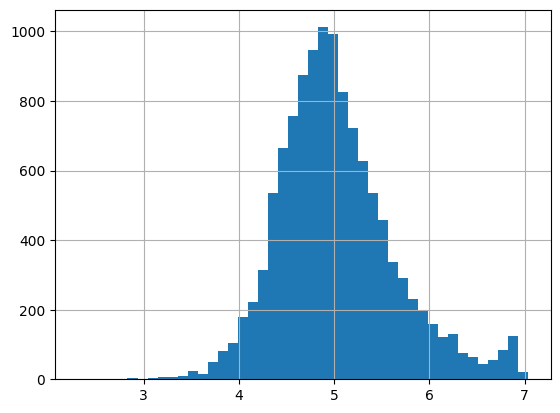

In [307]:
df["log_price"] = np.log(df["price"])
df["log_price"].hist(bins=45)

### Handling Outliers

### Handling Missing Values

I will have to choose between number_of_reviews, number_of_reviews_ltm (last twelve months) and review_scores_rating.

Note: Most ratings are null because they don't have any review

In [ ]:
(df.loc[df["review_scores_rating"].isna(), "number_of_reviews"]>0).sum()

np.int64(8)

### Data Type Conversion

## Save Preprocessed Data to File

In [ ]:
df.to_csv("../data/processed/florence_processed.csv", index=False)